# First Practical Laboratory: Deep Learning Architecture Experimentation

**Machine Learning Technologies (MUCEIM)**

**Student Name:** Guillermo Gracia Rebullida

**Date:** 23/11/2025

---

This notebook provides a classification problem for the Fashion MNIST data set using neural networks with different structures. The main goal is to compare all the structures and obtain conclusions from the results.

---

## 1. Import Libraries

Import all necessary libraries for your experiments.

In [ ]:
# Import necessary libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.utils import to_categorical
import time
import matplotlib.pyplot as plt


# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Check TensorFlow version
print(f"TensorFlow version: {tf.__version__}")

# Check if GPU is available
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU available: []


## 2. Dataset Selection and Loading

We consider the Fashion MNIST dataset.

In [ ]:
from tensorflow.keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Inspect the dataset
# Print shapes, data types, and visualize sample images

print("Size of an image: ", x_train[0].shape,
      "Type of a pixel: ", type(x_train[0, 0, 0]))

print("Information of y: ", type(y_train),
      "\nType of y or labels: ", y_train.shape,
      "\nType of each y or label: ", type(y_train[0]),
      "\nMin and max values in y: ", min(y_train), max(y_train))

def visualize_example(x):
    plt.figure()
    plt.imshow(x)
    plt.colorbar()
    plt.grid(False)
    plt.show()


Size of an image:  (28, 28) Type of a pixel:  <class 'numpy.uint8'>
Information of y:  <class 'numpy.ndarray'> 
Type of y or labels:  (60000,) 
Type of each y or label:  <class 'numpy.uint8'> 
Min and max values in y:  0 9


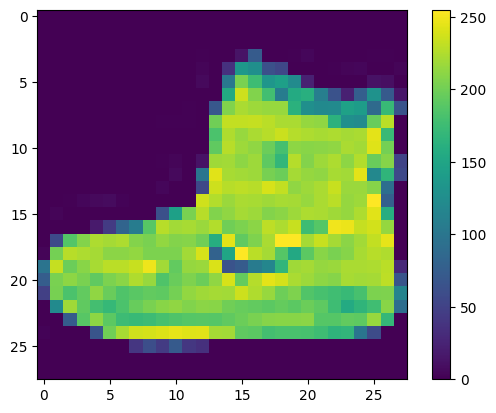

In [ ]:
visualize_example(x_train[0])

### Dataset Choice Justification

**Dataset Selected:** : Fashion Mnist

**Justification:** In my case, I have selected the Fashion Mnist since it can be a difficult dataset and a difficult classification problem. Apart from that, I have already seen Neural networks in my degree and already worked with the MNIST dataset.

## 3. Data Preprocessing

Apply necessary preprocessing steps:
- Normalization (e.g., scaling pixel values to [0,1])
- One-hot encoding for labels (if needed)
- Train/validation split
- Any dataset-specific preprocessing



In this case, we have applied data normalization for scaling the pixels values to [0,1], one hot encoding, and converted the images into a unique one dimensional array.

In [ ]:
# Preprocessing code

# Data normalization

x_train = x_train / 255.0
x_test = x_test / 255.0

# One hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


# All images into a unique one-dimensional array
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

## 4. Baseline Model

Define, compile, and train a simple baseline model. This will serve as your point of comparison for all subsequent experiments.

**Baseline Architecture Description:**
As our baseline model we consider a perceptron with sequential structure.The layers are added one after the other. We use 3 dense Layers with 128, 64, neurons and  Rectified Linear Unit (relu) activation function. It introduces non-linearity, allowing the network to learn complex relationships in the data.
The last layer has 10 neurons that represent the 10 classes of the problem, we use softmax activation typically used for multi-class classification. It ensures the output is a probability vector, indicating the network's confidence for each of the 10 classes.

Our training Variables are a 64 batch size The number of samples processed before the model's internal parameters (weights) are updated during training.Epochs (40): The number of times the learning algorithm will work through the entire training dataset.This model is a typical and efficient baseline for tasks that require mapping a large, fixed-size input vector (784) to one of ten distinct classes.

In [ ]:
# Define baseline model

# Variables with required data
batch_size = 64
epochs = 40

# We create the model
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(784,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile baseline model

model.compile(loss='categorical_crossentropy',
             optimizer='sgd',
             metrics=['accuracy'])





In [ ]:
# Train baseline model

start = time.time()

hist = model.fit(x_train, y_train,
                   batch_size = batch_size,
                   epochs=epochs,
                   verbose=1,
                   validation_split = .2,   #80% 20% in training data set, with an extra test set for final validation
                   shuffle = True)
train_time0 = time.time() - start

Epoch 1/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5744 - loss: 1.3548 - val_accuracy: 0.7809 - val_loss: 0.6494
Epoch 2/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7908 - loss: 0.6194 - val_accuracy: 0.8148 - val_loss: 0.5412
Epoch 3/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8178 - loss: 0.5266 - val_accuracy: 0.8290 - val_loss: 0.4984
Epoch 4/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8330 - loss: 0.4858 - val_accuracy: 0.8366 - val_loss: 0.4741
Epoch 5/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8400 - loss: 0.4613 - val_accuracy: 0.8407 - val_loss: 0.4571
Epoch 6/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8460 - loss: 0.4437 - val_accuracy: 0.8451 - val_loss: 0.4439
Epoch 7/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8508 - loss: 0.4297 - val_accuracy: 0.8501 - val_loss: 0.4335
Epoch 8/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8549 - loss: 0.4179 - val_accuracy: 0.

In [ ]:
# Evaluation on the test set

test_accuracy0 = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", test_accuracy0[1])

Test accuracy: 0.8711000084877014


### Analysis of Baseline Model

Plot the training history and evaluate the model. Analyze its performance characteristics.

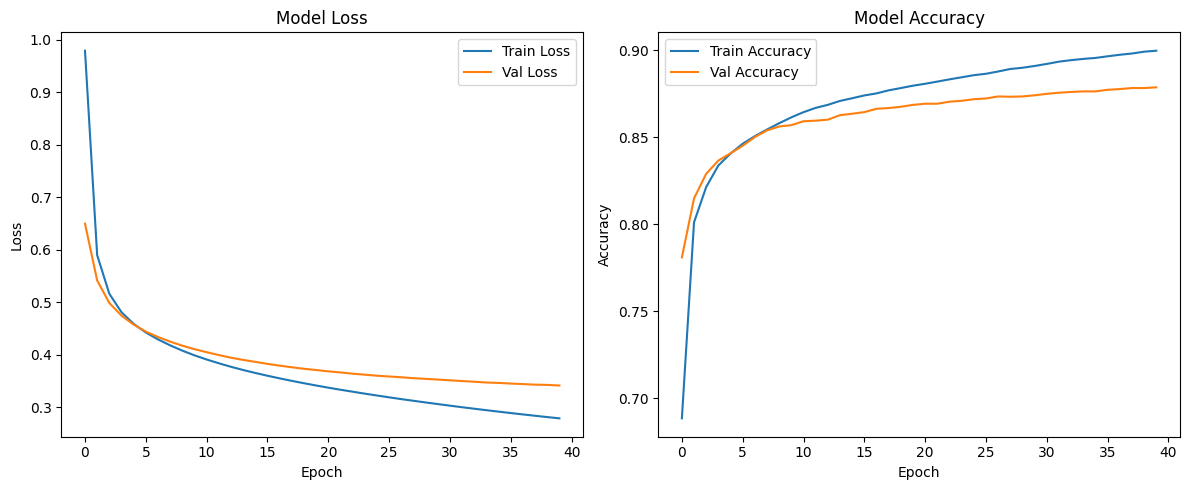

In [ ]:
# Plot results and compare with baseline

# Combined figure for loss and accuracy
plt.figure(figsize=(12, 5))


# 1. Loss subplot

plt.subplot(1, 2, 1)
plt.plot(hist.history['loss'], label='Train Loss')
plt.plot(hist.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()



# 2. Accuracy subplot

plt.subplot(1, 2, 2)
plt.plot(hist.history['accuracy'], label='Train Accuracy')
plt.plot(hist.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


plt.tight_layout()
plt.show()


**Baseline Model Analysis:**


- Final training and validation accuracy/loss: the training of the model works well. The values of the model starts with [accuracy: 0.5709 - loss: 1.3580 - val_accuracy: 0.7797 - val_loss: 0.6635] and after the trainig they end in [accuracy: 0.9012 - loss: 0.2773 - val_accuracy: 0.8809 - val_loss: 0.3417]. Which demonstrates the model is training well and adapting to the dataset.

- Since the gap between the training and the validation is not high, both numerically and graphically, we can think that the model adapts well to unseen data and so there is no overfitting.

- The model's accuracy is high considering we have 10 different classes and the probability of an image to be in a certain class is 1/10= 0.1. Consequently the model predicts well most cases and pretty much better than random guessing.

We consider that by changing the structure, introducing cross validation or dropout we may improve the results.

## 5. Systematic Experimentation

Conduct at least **THREE** systematic experiments. For each experiment:
1. State your hypothesis clearly
2. Implement the architectural variation
3. Train and evaluate the model
4. Plot and analyze the results
5. Compare with the baseline

---

### Experiment 1: Effect of Network Depth and neurons

**Hypothesis:** Adding another layout with 32 neurons may improve the metrics and the results.

In [ ]:
# Define Experiment 1 model


# Variables with required data
batch_size = 64
epochs = 40

# We create the model
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(784,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile and train Experiment 1 model

model.compile(loss='categorical_crossentropy',
             optimizer='sgd',
             metrics=['accuracy'])


In [ ]:
# Train baseline model

start = time.time()
hist1 = model.fit(x_train, y_train,
                   batch_size = batch_size,
                   epochs=epochs,
                   verbose=1,
                   validation_split = .2,   #80% 20% in training data set, with an extra test set for final validation
                   shuffle = True)
train_time1= time.time() - start


Epoch 1/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5504 - loss: 1.3901 - val_accuracy: 0.7820 - val_loss: 0.6332
Epoch 2/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7876 - loss: 0.6125 - val_accuracy: 0.8168 - val_loss: 0.5338
Epoch 3/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8154 - loss: 0.5254 - val_accuracy: 0.8326 - val_loss: 0.4920
Epoch 4/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8307 - loss: 0.4851 - val_accuracy: 0.8404 - val_loss: 0.4666
Epoch 5/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8387 - loss: 0.4592 - val_accuracy: 0.8472 - val_loss: 0.4484
Epoch 6/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8466 - loss: 0.4398 - val_accuracy: 0.8509 - val_loss: 0.4341
Epoch 7/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8515 - loss: 0.4241 - val_accuracy: 0.8549 - val_loss: 0.4221
Epoch 8/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8564 - loss: 0.4105 - val_accuracy: 0.

In [ ]:
# Evaluation on the test set

test_accuracy1 = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", test_accuracy1[1])

Test accuracy: 0.8748999834060669


#### Analysis of Experiment 1

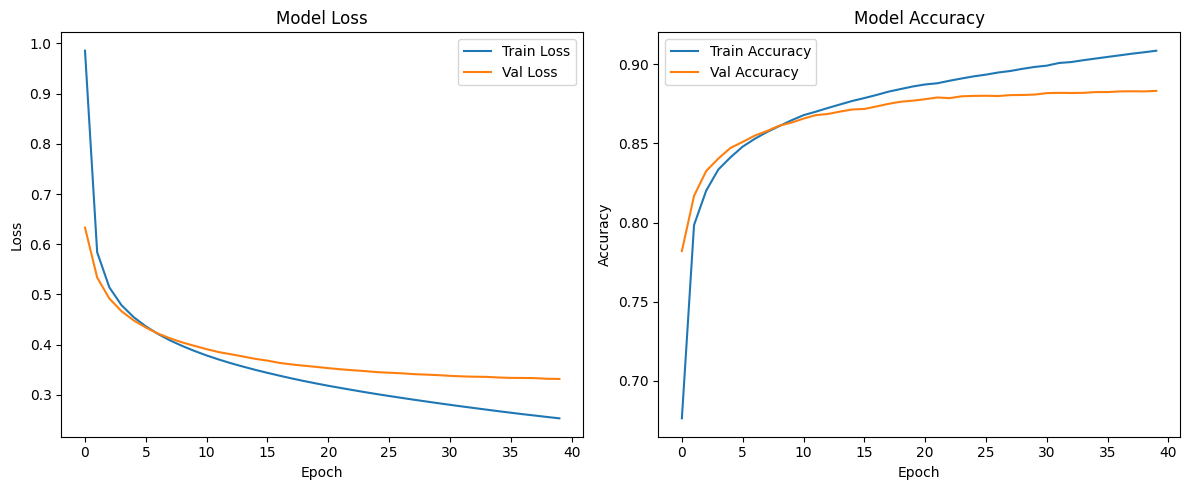

In [ ]:
# Plot results and compare with baseline

# Combined figure for loss and accuracy
plt.figure(figsize=(12, 5))


# 1. Loss subplot

plt.subplot(1, 2, 1)
plt.plot(hist1.history['loss'], label='Train Loss')
plt.plot(hist1.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()



# 2. Accuracy subplot

plt.subplot(1, 2, 2)
plt.plot(hist1.history['accuracy'], label='Train Accuracy')
plt.plot(hist1.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


plt.tight_layout()
plt.show()


**Experiment 1 Analysis:**

The results obtained support and our hypothesis and improves by a little the results obtained. Using the baseline model we had: [accuracy: 0.9066 - loss: 0.2527 - val_accuracy: 0.8784 - val_loss: 0.3465] and with the new model [accuracy: 0.9012 - loss: 0.2773 - val_accuracy: 0.8809 - val_loss: 0.3417]

We may expect that more complex in the system would improve the performance, however, the results obtained shows that the metrics are similar and the results don't improve greatly. This is a good proof that model complexity doesn't necesarily mean a better model for the problem.

---

### Experiment 2: Effect of Dropout Regularization and one more layer

**Hypothesis:** Since the results with one more layer have improved. We add another layer but include a 0.5 dropout in each layer to reduce overfitting"

In [ ]:
# Define baseline model

# Variables with required data
batch_size = 64
epochs = 40

# We create the model
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(784,)))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile and train Experiment 2 model

model.compile(loss='categorical_crossentropy',
             optimizer='sgd',
             metrics=['accuracy'])


In [ ]:
# Train baseline model

start = time.time()

hist2 = model.fit(x_train, y_train,
                   batch_size = batch_size,
                   epochs=epochs,
                   verbose=1,
                   validation_split = .2,   #80% 20% in training data set, with an extra test set for final validation
                   shuffle = True)

train_time2= time.time() - start

Epoch 1/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2084 - loss: 2.1397 - val_accuracy: 0.6173 - val_loss: 1.2670
Epoch 2/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4157 - loss: 1.5248 - val_accuracy: 0.6758 - val_loss: 0.9292
Epoch 3/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5099 - loss: 1.2496 - val_accuracy: 0.6982 - val_loss: 0.8140
Epoch 4/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5586 - loss: 1.1203 - val_accuracy: 0.6792 - val_loss: 0.7654
Epoch 5/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5932 - loss: 1.0373 - val_accuracy: 0.6820 - val_loss: 0.7272
Epoch 6/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6125 - loss: 0.9779 - val_accuracy: 0.7044 - val_loss: 0.7119
Epoch 7/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6334 - loss: 0.9380 - val_accuracy: 0.7298 - val_loss: 0.6920
Epoch 8/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6426 - loss: 0.9136 - val_accuracy: 0.

In [ ]:
# Evaluation on the test set

test_accuracy2 = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", test_accuracy2[1])

Test accuracy: 0.8270000219345093


#### Analysis of Experiment 2

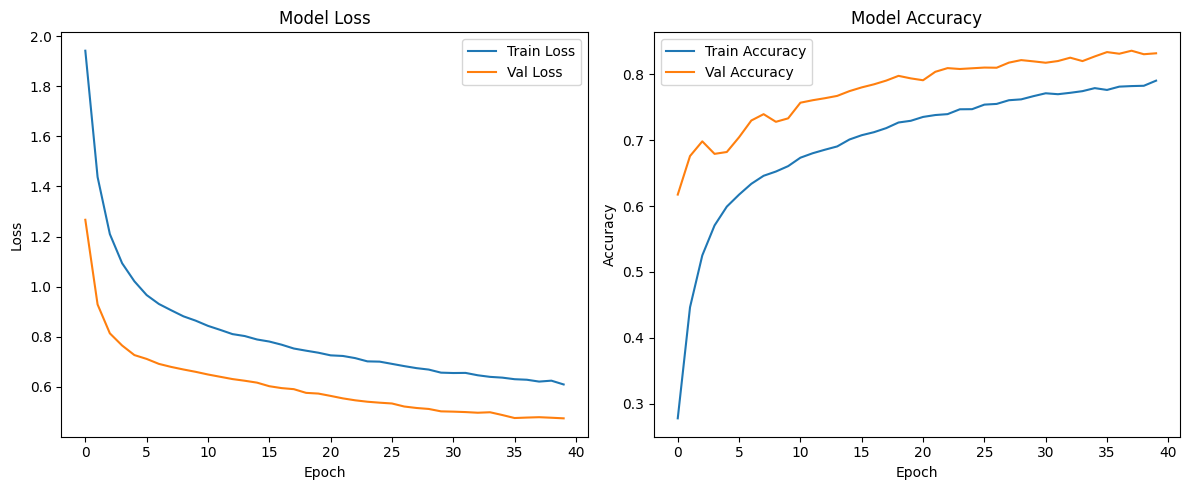

In [ ]:
# Plot results and compare with baseline

# Combined figure for loss and accuracy
plt.figure(figsize=(12, 5))


# 1. Loss subplot

plt.subplot(1, 2, 1)
plt.plot(hist2.history['loss'], label='Train Loss')
plt.plot(hist2.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()



# 2. Accuracy subplot

plt.subplot(1, 2, 2)
plt.plot(hist2.history['accuracy'], label='Train Accuracy')
plt.plot(hist2.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


plt.tight_layout()
plt.show()


**Experiment 2 Analysis:**

In this case, the dropout effect did not improve the training, in the same conditions as before. The training was longer and obtained lower loss and accuracy, and actually since the gap between validation and training loss and accuracy is higher we have induced more overfitting that the one that was before.

Consequently the results obtained shows the model performs worst than the baseline model or the ones before.

---

### Experiment 3: Effect of activation functions and optimizer

**Hypothesis:** The use of another activation function and another optimizer may improve the accuracy

In [ ]:
# Define Experiment 3 model


# Variables with required data
batch_size = 64
epochs = 40

# We create the model
model = Sequential()
model.add(Dense(128, activation='elu', input_shape=(784,)))
model.add(Dense(64, activation='elu'))
model.add(Dense(32, activation='elu'))
model.add(Dense(10, activation='softmax'))
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile and train Experiment 3 model

model.compile(loss='categorical_crossentropy',
             optimizer='Adam',
             metrics=['accuracy'])


start= time.time()

hist3 = model.fit(x_train, y_train,
                   batch_size = batch_size,
                   epochs=epochs,
                   verbose=1,
                   validation_split = .2,   #80% 20% in training data set, with an extra test set for final validation
                   shuffle = True)

train_time3 = time.time() - start


Epoch 1/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7576 - loss: 0.6844 - val_accuracy: 0.8542 - val_loss: 0.4041
Epoch 2/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8577 - loss: 0.3918 - val_accuracy: 0.8627 - val_loss: 0.3781
Epoch 3/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8717 - loss: 0.3500 - val_accuracy: 0.8683 - val_loss: 0.3660
Epoch 4/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8797 - loss: 0.3242 - val_accuracy: 0.8723 - val_loss: 0.3557
Epoch 5/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8872 - loss: 0.3029 - val_accuracy: 0.8753 - val_loss: 0.3507
Epoch 6/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8943 - loss: 0.2854 - val_accuracy: 0.8775 - val_loss: 0.3525
Epoch 7/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8988 - loss: 0.2705 - val_accuracy: 0.8768 - val_loss: 0.3583
Epoch 8/40
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9038 - loss: 0.2576 - val_accuracy: 0.

In [ ]:
# Evaluation on the test set

test_accuracy3 = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", test_accuracy3[1])

Test accuracy: 0.873199999332428


#### Analysis of Experiment 3

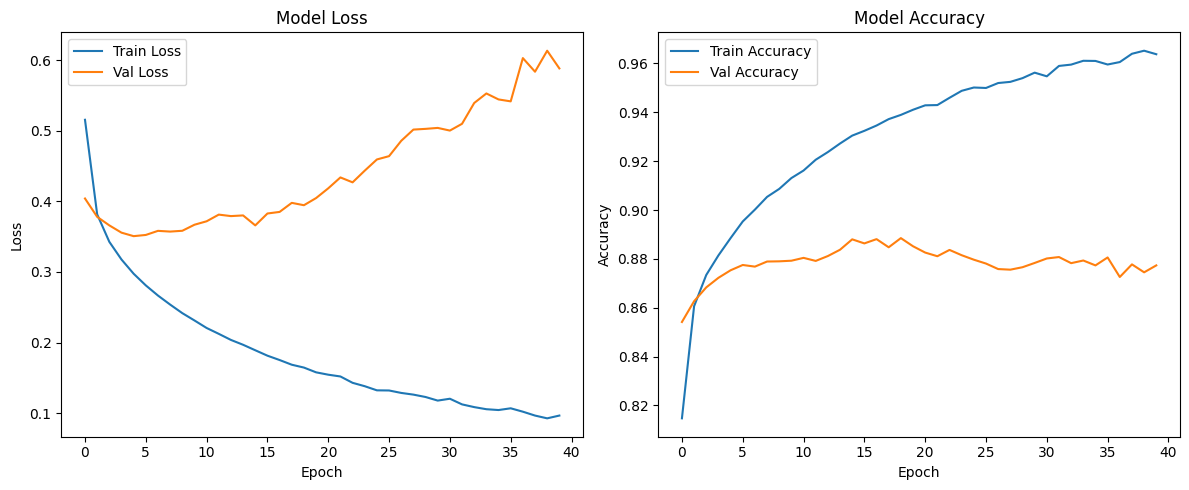

In [ ]:
# Plot results and compare with baseline

# Combined figure for loss and accuracy
plt.figure(figsize=(12, 5))


# 1. Loss subplot

plt.subplot(1, 2, 1)
plt.plot(hist3.history['loss'], label='Train Loss')
plt.plot(hist3.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()



# 2. Accuracy subplot

plt.subplot(1, 2, 2)
plt.plot(hist3.history['accuracy'], label='Train Accuracy')
plt.plot(hist3.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


plt.tight_layout()
plt.show()


**Experiment 3 Analysis:**

In this case, using the Adam optimizer have done the training longer. The metrics obtained shows best results in training
[accuracy: 0.9648 - loss: 0.0941 - val_accuracy: 0.8773 - val_loss: 0.5915], but the loss function shows a high difference between the training and validation, which implies overfitting.

---

## 6. Comprehensive Comparison

Create a summary comparison of all your experiments.

In [ ]:
experiments = {
    "Baseline": {
        "history": hist,
        "train_time": train_time0,
        "test_accuracy": test_accuracy0[1]
    },
    "Different layers and neurons": {
        "history": hist1,
        "train_time": train_time1,
        "test_accuracy": test_accuracy1[1]
    },
    "Dropout effect": {
        "history": hist2,
        "train_time": train_time2,
        "test_accuracy": test_accuracy2[1]
    },
    "Adam and eLu": {
        "history": hist3,
        "train_time": train_time3,
        "test_accuracy": test_accuracy3[1]
    }
}

rows = []

for name, data in experiments.items():
    h = data["history"].history
    train_time = data["train_time"]

    row = {
        "Experiment": name,
        "Final Train Accuracy": h["accuracy"][-1],
        "Final Val Accuracy": h["val_accuracy"][-1],
        "Final Train Loss": h["loss"][-1],
        "Final Val Loss": h["val_loss"][-1],
        "Training Time (s)": train_time,
        "Test Accuracy": data["test_accuracy"]
    }

    rows.append(row)

comparison_table = pd.DataFrame(rows)
print("\n=== Experiment Comparison Table ===\n")
print(comparison_table)




=== Experiment Comparison Table ===

                     Experiment  Final Train Accuracy  Final Val Accuracy  \
0                      Baseline              0.899708            0.878667   
1  Different layers and neurons              0.908542            0.883167   
2                Dropout effect              0.790292            0.831833   
3                  Adam and eLu              0.963771            0.877333   

   Final Train Loss  Final Val Loss  Training Time (s)  Test Accuracy  
0          0.278617        0.341154         142.268239         0.8711  
1          0.253275        0.331729         143.988711         0.8749  
2          0.609976        0.474814         156.876870         0.8270  
3          0.096702        0.588283         185.725896         0.8732  


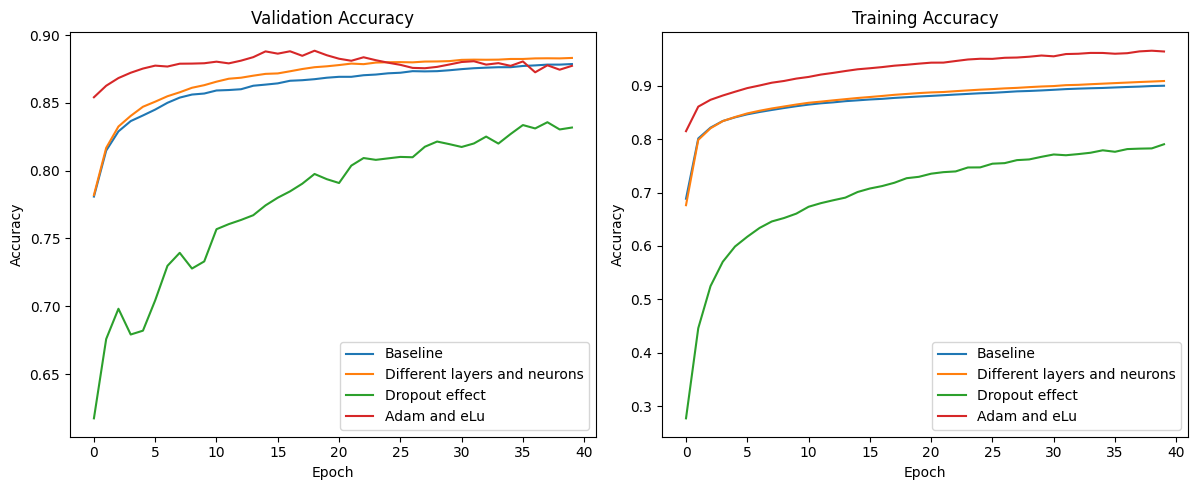

In [ ]:


def plot_comparative_metrics(experiments):
    plt.figure(figsize=(18, 5))

    # ----------------------------
    # 1. Validation Accuracy
    # ----------------------------
    plt.subplot(1, 3, 1)
    for name, data in experiments.items():
        plt.plot(data["history"].history['val_accuracy'], label=name)
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()


    # ----------------------------
    # 2. Training Accuracy
    # ----------------------------
    plt.subplot(1, 3, 2)
    for name, data in experiments.items():
        plt.plot(data["history"].history['accuracy'], label=name)
    plt.title('Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()




    plt.tight_layout()
    plt.show()


# ----------------------------
# Example usage
# ----------------------------
plot_comparative_metrics(experiments)



## 7. Final Conclusion

Here we summarize my key findings from all experiments. In this case, we can think that a general neural networks adapts well to the data. However, it's difficult to choose the parameters in order to improve the peformance.

**Key Findings:**

We have seen that the baseline model exhibited balanced performance, with training and validation accuracies of approximately 90% and 88%, respectively, and a test accuracy of 86.8%. The model showed no significant overfitting or underfitting, serving as a strong reference for comparison.

In the case of using different Layers and Neurons we see that modifying the architecture slightly improved both training and validation accuracies (91% and 88%, respectively) and achieved the highest test accuracy of 87.4%. Furthermore, training time decreased slightly, indicating an efficient architecture. So here we see that adjusting layers and neurons can improve generalization without overfitting.

In the case of the Dropout Effect we saw that it significantly reduced training accuracy (80%) while slightly lowering validation accuracy (86%). In this case, test accuracy decreased to 85%, indicating underfitting due to excessive regularization. In conclusion the over regularization with dropout can harm performance when the baseline model already generalizes well.

Finally, the Adam Optimizer + eLu Activation expermient achieved the highest training accuracy (96%), but validation and test accuracies were similar to the baseline (87.3% and 86.5%, respectively). We also see that the model overfits strongly, indicated by a very low training loss (0.097) and high validation loss (0.632). Therefore, we see that the fast convergence with Adam and aggressive activations can lead to overfitting.

In this case we consider the second experiment the most effective since it doesn't include overfitting and obtains the highest accuracy. Showing, once again that just by adding 1 thing (such one layer with few neurons) we can improve the model more than making it more complex.

We have to consider that all of the cases have been produced in the same circumstances (same batch size and epochs) in order to compare the results with a few little iterations. However, by adding more epochs or equivalently using early stopping we might perform the results.


## 8. AI Assistant Usage Documentation

Document how you used AI assistants in this laboratory work.

**AI Assistants Used:** The main assistants used have been ChatGPT and Gemini.

**How I Used AI Assistants:**


- Used ChatGpt to explain the difference between SGD and ADAM optimizers and what should convert faster.
- Used ChatGPT to help understand how to introduce Dropout and how it changes overfitting.

**Code Sections Influenced by AI:**

-The tables summary for all of the experiments were suggested by Gemini.
- How to put all the graphs together was suggested by ChatGPT.

**My Understanding:**

While I have used Generative tools, I have reviewed all AI-generated code and understand how it works and why the results obtained are this ones. also have adapted the code for the tables and graphics.


---

## Submission Checklist

Before submitting, ensure you have:

- [ ] Filled in your name and date at the top of this notebook
- [ ] Completed all required sections and code cells
- [ ] Run the entire notebook from top to bottom without errors (`Runtime > Restart and run all`)
- [ ] Documented your analysis in all markdown cells
- [ ] Created clear and informative visualizations
- [ ] Documented your AI assistant usage
- [ ] Shared this notebook with "Anyone with the link can view"
- [ ] Included the link to this notebook in your PDF report
- [ ] Prepared your PDF report with all required sections

**Good luck!**